In [1]:
import ee
import geemap
import pandas as pd
import matplotlib.pyplot as plt

ee.Initialize()

In [2]:
counties = ee.FeatureCollection("FAO/GAUL/2015/level2")

makueni = counties.filter(
    ee.Filter.And(
        ee.Filter.eq("ADM0_NAME", "Kenya"),
        ee.Filter.eq("ADM2_NAME", "Makueni")
    )
)

In [3]:
worldcover = ee.ImageCollection("ESA/WorldCover/v200").first() # ESA WorldCover is a labelisation of the map. Here for cropland

In [4]:
cropland = worldcover.eq(40).clip(makueni) # 40 = cropland ; "Keep only the pixels labeled as Cropland."

In [5]:
Map = geemap.Map(center=[-2.25, 37.9], zoom=9)

Map.addLayer(
    cropland,
    {"min": 0, "max": 1, "palette": ["white", "green"]},
    "Cropland mask"
)

#Map.addLayer(makueni, {"color": "red"}, "Makueni County")

Map

Map(center=[-2.25, 37.9], controls=(WidgetControl(options=['position', 'transparent_bg'], position='topright',…

In [6]:
s2 = (
    ee.ImageCollection("COPERNICUS/S2_SR_HARMONIZED")
    .filterBounds(makueni)
    .filterDate("2024-01-01", "2024-02-01")
    .filter(ee.Filter.lt("CLOUDY_PIXEL_PERCENTAGE", 20))
)

image = s2.median().clip(makueni)

ndvi = image.normalizedDifference(["B8", "B4"]).rename("NDVI")

In [7]:
ndvi_cropland = ndvi.updateMask(cropland) # Keep NDVI values only where cropland == 1

In [8]:
mean_ndvi_all = ndvi.reduceRegion(
    reducer=ee.Reducer.mean(),
    geometry=makueni.geometry(),
    scale=10,
    maxPixels=1e9
)

print("All pixels:", mean_ndvi_all.getInfo())

All pixels: {'NDVI': 0.6316708595939604}


In [9]:
mean_ndvi_cropland = ndvi_cropland.reduceRegion(
    reducer=ee.Reducer.mean(),
    geometry=makueni.geometry(),
    scale=10,
    maxPixels=1e9
)

print("Cropland only:", mean_ndvi_cropland.getInfo())

Cropland only: {'NDVI': 0.5901088861566653}


In [10]:
Map = geemap.Map(center=[-2.25, 37.9], zoom=9)

ndvi_vis = {
    "min": 0,
    "max": 0.8,
    "palette": ["brown", "yellow", "green"]
}

Map.addLayer(ndvi_cropland, ndvi_vis, "NDVI - Cropland only")
#Map.addLayer(makueni, {"color": "red"}, "Makueni County")

Map

Map(center=[-2.25, 37.9], controls=(WidgetControl(options=['position', 'transparent_bg'], position='topright',…

In [11]:
print("All pixels:", mean_ndvi_all.getInfo())
print("Cropland only:", mean_ndvi_cropland.getInfo())

All pixels: {'NDVI': 0.6316708595939604}
Cropland only: {'NDVI': 0.5901088861566653}


In [12]:
def monthly_mean_ndvi_cropland(start_date, end_date):
    
    s2 = (
        ee.ImageCollection("COPERNICUS/S2_SR_HARMONIZED")
        .filterBounds(makueni)
        .filterDate(start_date, end_date)
        .filter(ee.Filter.lt("CLOUDY_PIXEL_PERCENTAGE", 20))
    )
    
    image = s2.median().clip(makueni)

    ndvi = image.normalizedDifference(
        ["B8", "B4"]
    ).rename("NDVI")
    
    ndvi_cropland = ndvi.updateMask(cropland)
    
    mean_ndvi = ndvi_cropland.reduceRegion(
        reducer=ee.Reducer.mean(),
        geometry=makueni.geometry(),
        scale=10,
        maxPixels=1e9
    )

    return mean_ndvi.get("NDVI")

In [13]:
months = pd.date_range(
    start="2020-01-01",
    end="2024-12-01",
    freq="MS"
)

results = []

for start in months:
    end = start + pd.DateOffset(months=1)

    value = monthly_mean_ndvi_cropland(
        start.strftime("%Y-%m-%d"),
        end.strftime("%Y-%m-%d")
    ).getInfo()

    results.append({
        "month": start,
        "mean_ndvi_cropland": value
    })

    print(start.strftime("%Y-%m"), value)

2020-01 0.5608350200128569
2020-02 0.5976646679125855
2020-03 0.6118655172182675
2020-04 0.5182487427317278
2020-05 0.4686635434682399
2020-06 0.41400475199595177
2020-07 0.31362780971955734
2020-08 0.27476586884153487
2020-09 0.19769044341741562
2020-10 0.22336736379803224
2020-11 0.2907452638758005
2020-12 0.5141577463095319
2021-01 0.527577106820659
2021-02 0.46708138204840777
2021-03 0.2573968440637799
2021-04 0.2473433485791409
2021-05 0.2542004249608586
2021-06 0.42409560983909383
2021-07 0.20285448577252527
2021-08 0.21199641109523232
2021-09 0.1576966962948986
2021-10 0.17950156419446045
2021-11 0.17701802080184542
2021-12 0.48355113101083913
2022-01 0.5778960193821089
2022-02 0.35359122577366664
2022-03 0.2907355117938061
2022-04 0.28706782690203003
2022-05 0.34688250785912267
2022-06 0.1859949723498632
2022-07 0.23511173914126202
2022-08 0.16111928349569388
2022-09 0.17133743613999963
2022-10 0.1647135068011268
2022-11 0.1297063041731724
2022-12 0.5116383384157411
2023-01 0.4

In [14]:
crop_ndvi_df = pd.DataFrame(results)
crop_ndvi_df.head()

,month,mean_ndvi_cropland
0,2020-01-01,0.560835
1,2020-02-01,0.597665
2,2020-03-01,0.611866
3,2020-04-01,0.518249
4,2020-05-01,0.468664


In [15]:
crop_ndvi_df.to_csv(
    "../outputs/makueni_monthly_ndvi_cropland_2020_2024.csv",
    index=False
)

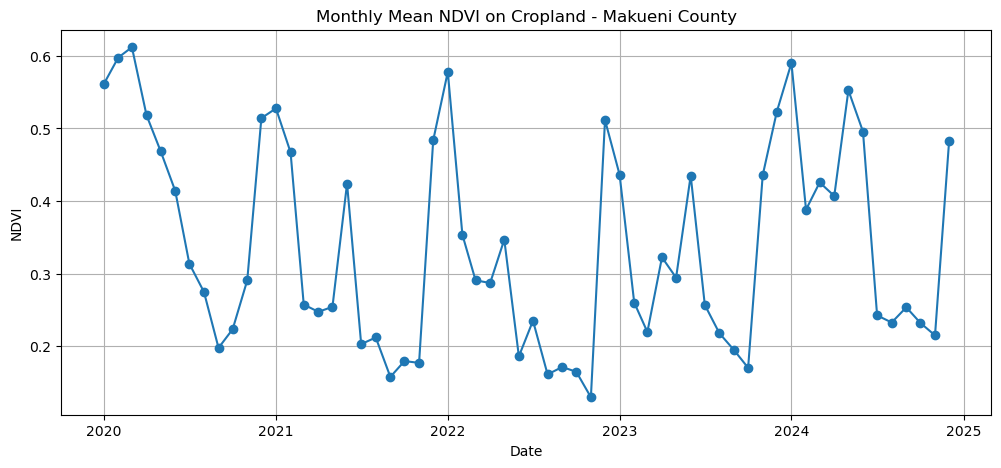

In [16]:
fig, ax = plt.subplots(figsize=(12,5))

ax.plot(
    crop_ndvi_df["month"],
    crop_ndvi_df["mean_ndvi_cropland"],
    marker="o"
)

ax.set_title("Monthly Mean NDVI on Cropland - Makueni County")
ax.set_ylabel("NDVI")
ax.set_xlabel("Date")
ax.grid(True)

fig.savefig(
    "../docs/images/makueni_ndvi_cropland_timeseries_2020_2024.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()